* OBJ: Estimar cuántas orders no ingresaron tras activar determinados triggers determinado dia
* QUERY: 2026-07-13 estimacion_orders_bloqueadas_por_triggers_de_cierre

## Data Load

#### actividad de los trigger de cierre y la estimación de orders bloqueadas

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import pandas as pd
# file_name = 'all_closing_triggers_07.13_07.26.csv'

# file_path_main = '/content/drive/MyDrive/Triggers & HDM/Triggers de Cierre/'
# file_path = file_path_main + file_name
# df_volume_raw = pd.read_csv(file_path)
# df_volume_raw.head(3) 

In [2]:
import pandas as pd
import gspread
from google.colab import auth
import google.auth

auth.authenticate_user()

credentials, _ = google.auth.default(scopes=[
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive"
])

gc = gspread.authorize(credentials)

sheet_id = "1CcyDyHWUf0grSwfNyBCPA-rJd-bspUwcQymW56cBbu4"
sheet_name = "triggers_activity"

worksheet = gc.open_by_key(sheet_id).worksheet(sheet_name)
data = worksheet.get_all_values()
df_volume_raw = pd.DataFrame(data[1:], columns=data[0])

df_volume_raw.head(6) # primeras dos semanas de junio

,closure_id,date,day_of_week,day_of_week_name,partner_id,vendor_name,franchise_name,grade,notes,category_name,...,to_date_local,duration_minutes,weeks_with_free_time,observed_orders_free_last_4_weeks,blocked_minutes_last_4_weeks,free_minutes_last_4_weeks,historical_free_coverage_pct,avg_orders_last_4_weeks_free_periods,orders_vendor_date,orders_vendor_date_seamless
0,966,2026-08-17,1,Domingo,151620,Domino's Pizza - Arica,Domino's Pizza,A,v1,,...,2026-08-17 0:00:03,0.05,4.00,0.00,0.00,0.20,100.00,0.00,57.00,50.00
1,1070,2026-08-17,1,Domingo,195169,El Bajon De Los Chamos,,B,v1,,...,2026-08-17 0:49:05,13.00,4.00,2.00,0.00,52.00,100.00,0.50,17.00,13.00
2,276,2026-08-17,2,Lunes,67195,Tarragona Lider Chillan,Tarragona,A,v1,,...,2026-08-17 10:48:05,10.00,4.00,1.00,0.00,40.00,100.00,0.25,29.00,23.00
3,1671,2026-08-17,2,Lunes,432141,Dunkin Lider Chillán,Dunkin Donuts,A,v1,,...,2026-08-17 10:53:01,13.00,4.00,1.00,0.00,52.00,100.00,0.25,23.00,22.00
4,16,2026-08-17,2,Lunes,60326,Restaurant Kitchen Wok Comida China Sushi Thai,,A,v1,,...,2026-08-17 12:22:05,1.05,4.00,1.00,0.00,4.20,100.00,0.25,28.00,25.00
5,313,2026-08-17,2,Lunes,68343,Topissimo Restaurant 1,,C,v1,,...,2026-08-17 12:38:01,13.98,4.00,0.00,0.00,55.93,100.00,0.00,11.00,9.00


#### seamless de cada grade normal/saturado

In [3]:
import pandas as pd
import gspread
from google.colab import auth
import google.auth

auth.authenticate_user()

credentials, _ = google.auth.default(scopes=[
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive"
])

gc = gspread.authorize(credentials)

sheet_id = "1CcyDyHWUf0grSwfNyBCPA-rJd-bspUwcQymW56cBbu4"
sheet_name = "main"

worksheet = gc.open_by_key(sheet_id).worksheet(sheet_name)
data = worksheet.get_all_values()
df_efficiency_raw = pd.DataFrame(data[1:], columns=data[0])

df_efficiency_raw.head(6) # primeras dos semanas de junio

,grade,status,minutes,total_orders,seamless_orders,seamless_rate,seamless_rate_pct
0,A,Normal,"2,871,999.00","169,122.00","136,005.00",0.80,80.42
1,A,Saturado,"2,159.00",216.00,104.00,0.48,48.15
2,AA,Normal,"1,264,563.00","112,793.00","89,551.00",0.79,79.39
3,AA,Saturado,"1,228.00",99.00,43.00,0.43,43.43
4,AAA,Normal,"669,184.00","90,281.00","66,620.00",0.74,73.79
5,AAA,Saturado,"1,936.00",170.00,60.00,0.35,35.29


#### Diagnóstico de tipos antes de transformar
Esta celda no modifica los DataFrames: muestra qué llegó desde Google Sheets y qué valores no podrían convertirse a número.

In [4]:
numeric_columns_volume = [
    "duration_minutes",
    "weeks_with_free_time",
    "observed_orders_free_last_4_weeks",
    "blocked_minutes_last_4_weeks",
    "free_minutes_last_4_weeks",
    "historical_free_coverage_pct",
    "avg_orders_last_4_weeks_free_periods",
    "orders_vendor_date",
    "orders_vendor_date_seamless",
]

numeric_columns_efficiency = [
    "minutes",
    "total_orders",
    "seamless_orders",
    "seamless_rate",
    "seamless_rate_pct",
]

def parse_sheet_number(series):
    text = series.astype("string").str.strip()
    text = text.mask(text.eq(""))
    return pd.to_numeric(
        text.str.replace(",", "", regex=False),
        errors="coerce"
    )

def audit_numeric_columns(df, df_name, columns):
    print(f"\n{df_name}: shape={df.shape}")
    print("Dtypes al llegar desde Google Sheets:")
    print(df.dtypes.to_string())

    audit_rows = []
    for column in columns:
        if column not in df.columns:
            audit_rows.append({
                "column": column,
                "dtype_before": "MISSING",
                "non_empty": None,
                "parsed_ok": None,
                "invalid_non_empty": None,
                "invalid_examples": None,
            })
            continue

        raw_text = df[column].astype("string").str.strip()
        non_empty = raw_text.notna() & raw_text.ne("")
        parsed = parse_sheet_number(df[column])
        invalid = non_empty & parsed.isna()

        audit_rows.append({
            "column": column,
            "dtype_before": str(df[column].dtype),
            "non_empty": int(non_empty.sum()),
            "parsed_ok": int((non_empty & parsed.notna()).sum()),
            "invalid_non_empty": int(invalid.sum()),
            "invalid_examples": raw_text[invalid].drop_duplicates().head(5).tolist(),
        })

    audit = pd.DataFrame(audit_rows)
    display(audit)
    return audit

audit_volume = audit_numeric_columns(
    df_volume_raw, "df_volume_raw", numeric_columns_volume
)
audit_efficiency = audit_numeric_columns(
    df_efficiency_raw, "df_efficiency_raw", numeric_columns_efficiency
)

parsed_dates = pd.to_datetime(df_volume_raw["date"], errors="coerce")
invalid_dates = df_volume_raw["date"].astype("string").str.strip().ne("") & parsed_dates.isna()
print(f"\nFechas no parseables: {int(invalid_dates.sum())}")
if invalid_dates.any():
    print(df_volume_raw.loc[invalid_dates, "date"].drop_duplicates().head(10).tolist())

print("\nValores de notes / trigger_type:")
print(df_volume_raw["notes"].value_counts(dropna=False).to_string())
print("\nValores de status:")
print(df_efficiency_raw["status"].value_counts(dropna=False).to_string())
print("\nGrades en actividad:", sorted(df_volume_raw["grade"].dropna().unique().tolist()))
print("Grades en eficiencia:", sorted(df_efficiency_raw["grade"].dropna().unique().tolist()))


df_volume_raw: shape=(2770, 24)
Dtypes al llegar desde Google Sheets:
closure_id                              object
date                                    object
day_of_week                             object
day_of_week_name                        object
partner_id                              object
vendor_name                             object
franchise_name                          object
grade                                   object
notes                                   object
category_name                           object
action                                  object
any_reviewed                            object
source_trigger_count                    object
from_date_local                         object
to_date_local                           object
duration_minutes                        object
weeks_with_free_time                    object
observed_orders_free_last_4_weeks       object
blocked_minutes_last_4_weeks            object
free_minutes_last_4_weeks           

,column,dtype_before,non_empty,parsed_ok,invalid_non_empty,invalid_examples
0,duration_minutes,object,2770,2770,0,[]
1,weeks_with_free_time,object,2770,2770,0,[]
2,observed_orders_free_last_4_weeks,object,2770,2770,0,[]
3,blocked_minutes_last_4_weeks,object,2770,2770,0,[]
4,free_minutes_last_4_weeks,object,2770,2770,0,[]
5,historical_free_coverage_pct,object,2770,2770,0,[]
6,avg_orders_last_4_weeks_free_periods,object,2758,2758,0,[]
7,orders_vendor_date,object,2770,2770,0,[]
8,orders_vendor_date_seamless,object,2770,2770,0,[]



df_efficiency_raw: shape=(13, 7)
Dtypes al llegar desde Google Sheets:
grade                object
status               object
minutes              object
total_orders         object
seamless_orders      object
seamless_rate        object
seamless_rate_pct    object


,column,dtype_before,non_empty,parsed_ok,invalid_non_empty,invalid_examples
0,minutes,object,13,13,0,[]
1,total_orders,object,13,13,0,[]
2,seamless_orders,object,13,13,0,[]
3,seamless_rate,object,13,13,0,[]
4,seamless_rate_pct,object,13,13,0,[]



Fechas no parseables: 0

Valores de notes / trigger_type:
notes
v1    2770

Valores de status:
status
Normal      7
Saturado    6

Grades en actividad: ['', 'A', 'AA', 'AAA', 'B', 'C', 'D', 'NA']
Grades en eficiencia: ['A', 'AA', 'AAA', 'B', 'C', 'D', 'NA']


#### Normalización explícita después del diagnóstico
La carga con `get_all_values()` devuelve texto. Sólo después de imprimir la auditoría convertimos las métricas necesarias.

In [5]:
missing_volume = [c for c in numeric_columns_volume if c not in df_volume_raw.columns]
missing_efficiency = [c for c in numeric_columns_efficiency if c not in df_efficiency_raw.columns]
invalid_volume = int(audit_volume["invalid_non_empty"].fillna(0).sum())
invalid_efficiency = int(audit_efficiency["invalid_non_empty"].fillna(0).sum())

if missing_volume or missing_efficiency:
    raise KeyError(
        f"Columnas faltantes. df_volume_raw={missing_volume}; "
        f"df_efficiency_raw={missing_efficiency}"
    )

if invalid_volume or invalid_efficiency:
    raise ValueError(
        f"Hay valores no vacíos que no se pudieron convertir: "
        f"df_volume_raw={invalid_volume}; df_efficiency_raw={invalid_efficiency}. "
        "Revisa la tabla de auditoría anterior antes de continuar."
    )

for column in numeric_columns_volume:
    df_volume_raw[column] = parse_sheet_number(df_volume_raw[column])

for column in numeric_columns_efficiency:
    df_efficiency_raw[column] = parse_sheet_number(df_efficiency_raw[column])

print("Tipos después de normalizar df_volume_raw:")
print(df_volume_raw[numeric_columns_volume].dtypes.to_string())
print("\nTipos después de normalizar df_efficiency_raw:")
print(df_efficiency_raw[numeric_columns_efficiency].dtypes.to_string())

Tipos después de normalizar df_volume_raw:
duration_minutes                        Float64
weeks_with_free_time                    Float64
observed_orders_free_last_4_weeks       Float64
blocked_minutes_last_4_weeks            Float64
free_minutes_last_4_weeks               Float64
historical_free_coverage_pct            Float64
avg_orders_last_4_weeks_free_periods    Float64
orders_vendor_date                      Float64
orders_vendor_date_seamless             Float64

Tipos después de normalizar df_efficiency_raw:
minutes              Float64
total_orders         Float64
seamless_orders      Float64
seamless_rate        Float64
seamless_rate_pct    Float64


In [6]:
# ESTIMAMOS CUANTAS ORDERS SEAMLESS HABÍAN EN LAS ORDERS BLOQUEADAS

# Tomamos solo el seamless de los estados saturados para las estimaciones.
df_saturated_rate = (
    df_efficiency_raw[df_efficiency_raw["status"] == "Saturado"]
    [["grade", "seamless_rate"]]
).copy()

duplicate_saturated_grades = df_saturated_rate["grade"].duplicated(keep=False)
print(f"Filas de tasas saturadas: {len(df_saturated_rate)}")
print(f"Grades saturados duplicados: {int(duplicate_saturated_grades.sum())}")
if duplicate_saturated_grades.any():
    display(df_saturated_rate.loc[duplicate_saturated_grades].sort_values("grade"))
    raise ValueError("Hay más de una tasa Saturado por grade; el merge multiplicaría filas.")

# Limpiar intentos previos para que la celda sea reejecutable.
columns_from_previous_run = [
    column for column in ["seamless_rate", "estimated_orders_seamless"]
    if column in df_volume_raw.columns
]
if columns_from_previous_run:
    df_volume_raw = df_volume_raw.drop(columns=columns_from_previous_run)

rows_before_merge = len(df_volume_raw)
df_volume_raw = df_volume_raw.merge(
    df_saturated_rate,
    on="grade",
    how="left",
    validate="many_to_one"
)
rows_after_merge = len(df_volume_raw)
missing_rate = df_volume_raw["seamless_rate"].isna()

print(f"Filas antes/después del merge: {rows_before_merge} / {rows_after_merge}")
print(f"Filas sin seamless_rate saturado: {int(missing_rate.sum())}")
if missing_rate.any():
    print("Grades sin tasa saturada:")
    print(df_volume_raw.loc[missing_rate, "grade"].value_counts(dropna=False).to_string())

# Conservamos el criterio original: un grade sin tasa saturada aporta 0 seamless estimado.
df_volume_raw["seamless_rate"] = df_volume_raw["seamless_rate"].fillna(0)
df_volume_raw["estimated_orders_seamless"] = (
    df_volume_raw["avg_orders_last_4_weeks_free_periods"]
    * df_volume_raw["seamless_rate"]
)

print("\nResumen de estimated_orders_seamless:")
print(df_volume_raw["estimated_orders_seamless"].describe().to_string())

Filas de tasas saturadas: 6
Grades saturados duplicados: 0
Filas antes/después del merge: 2770 / 2770
Filas sin seamless_rate saturado: 5
Grades sin tasa saturada:
grade
      3
NA    2

Resumen de estimated_orders_seamless:
count      2758.0
mean     0.313744
std      0.359118
min           0.0
25%           0.0
50%        0.2204
75%          0.48
max        3.3565


In [7]:
df_volume = df_volume_raw.copy()
df_volume['trigger_type'] = df_volume['notes']
import matplotlib.pyplot as plt

In [8]:
df_volume

,closure_id,date,day_of_week,day_of_week_name,partner_id,vendor_name,franchise_name,grade,notes,category_name,...,observed_orders_free_last_4_weeks,blocked_minutes_last_4_weeks,free_minutes_last_4_weeks,historical_free_coverage_pct,avg_orders_last_4_weeks_free_periods,orders_vendor_date,orders_vendor_date_seamless,seamless_rate,estimated_orders_seamless,trigger_type
0,966,2026-08-17,1,Domingo,151620,Domino's Pizza - Arica,Domino's Pizza,A,v1,,...,0.0,0.0,0.2,100.0,0.0,57.0,50.0,0.48,0.0,v1
1,1070,2026-08-17,1,Domingo,195169,El Bajon De Los Chamos,,B,v1,,...,2.0,0.0,52.0,100.0,0.5,17.0,13.0,0.51,0.255,v1
2,276,2026-08-17,2,Lunes,67195,Tarragona Lider Chillan,Tarragona,A,v1,,...,1.0,0.0,40.0,100.0,0.25,29.0,23.0,0.48,0.12,v1
3,1671,2026-08-17,2,Lunes,432141,Dunkin Lider Chillán,Dunkin Donuts,A,v1,,...,1.0,0.0,52.0,100.0,0.25,23.0,22.0,0.48,0.12,v1
4,16,2026-08-17,2,Lunes,60326,Restaurant Kitchen Wok Comida China Sushi Thai,,A,v1,,...,1.0,0.0,4.2,100.0,0.25,28.0,25.0,0.48,0.12,v1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2765,2606,2026-08-30,1,Domingo,594630,Sushi Ap Pop´s Papas Playa Brava,,A,v1,,...,2.0,10.02,29.98,74.96,0.67,52.0,33.0,0.48,0.3216,v1
2766,2070,2026-08-30,1,Domingo,528506,Texas Burger - Iquique,,C,v1,,...,0.0,13.0,39.0,75.0,0.0,8.0,6.0,0.44,0.0,v1
2767,2607,2026-08-30,1,Domingo,594630,Sushi Ap Pop´s Papas Playa Brava,,A,v1,,...,0.0,11.9,3.97,25.0,0.0,52.0,33.0,0.48,0.0,v1
2768,268,2026-08-30,1,Domingo,66489,McDonald's Iquique,McDonald's,AAA,v1,,...,4.0,40.88,34.92,46.06,2.17,147.0,84.0,0.35,0.7595,v1


## Data Visualization

### Horas activas para cada date y trigger

/tmp/ipykernel_1272/2975875248.py:109: UserWarning: Mismatched number of handles and labels: len(handles) = 1 len(labels) = 2
  ax.legend(


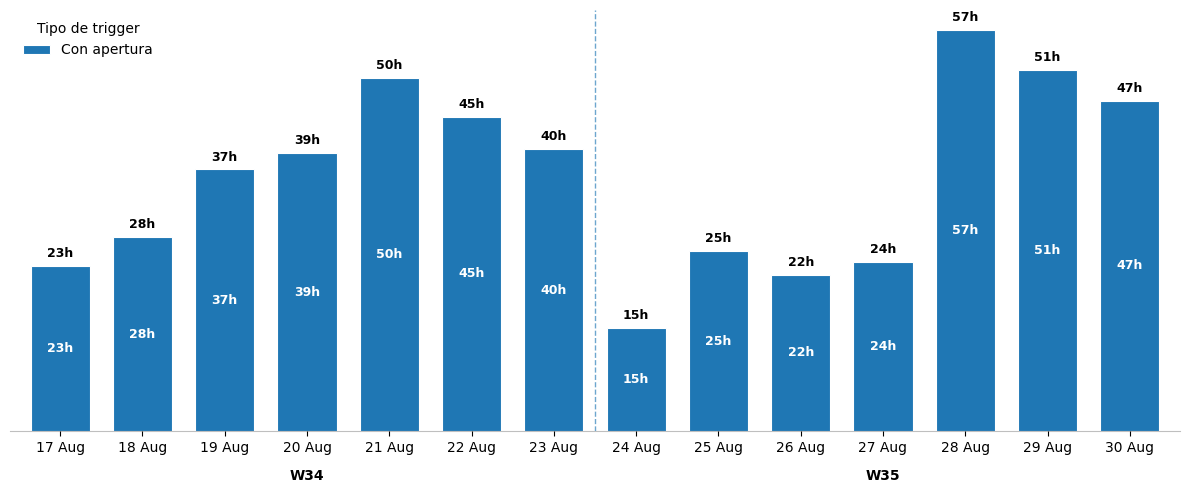

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

active_hours = (
    df_volume[df_volume["date"] > "2026-06-07"]
    .groupby(["date", "trigger_type"])["duration_minutes"]
    .sum()
    .div(60)
    .unstack(fill_value=0)
    .sort_index()
)

dates = pd.to_datetime(active_hours.index)
active_hours.index = dates.strftime("%d %b")

ax = active_hours.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    width=0.72,
    edgecolor="white",
    linewidth=0.8
)

# Guardar handles de barras ANTES de agregar axvline
handles, _ = ax.get_legend_handles_labels()

# Valores dentro de cada segmento
for container, col in zip(ax.containers, active_hours.columns):
    labels = [
        f"{v:.0f}h" if v >= 10 else ""
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        fontweight="bold",
        color="white" if col == "v1" else "black"
    )

# Total sobre cada barra
totals = active_hours.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + totals.max() * 0.015,
        f"{total:.0f}h",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Separación entre semanas
for i in range(1, len(dates)):
    if dates[i].isocalendar().week != dates[i - 1].isocalendar().week:
        ax.axvline(
            i - 0.5,
            linestyle="--",
            linewidth=1,
            alpha=0.65,
            label="_nolegend_"
        )

# Etiquetas de semana centradas bajo el eje X
week_numbers = dates.isocalendar().week.to_numpy()

week_groups = pd.DataFrame({
    "position": range(len(dates)),
    "week": week_numbers
})

for week, group in week_groups.groupby("week", sort=False):
    center = group["position"].mean()

    ax.text(
        center,
        -0.09,
        f"W{week}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        clip_on=False
    )

# ax.set_title(
#     "Horas activas por día y tipo de trigger",
#     loc="left",
#     fontsize=15,
#     fontweight="bold",
#     pad=18
# )

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_alpha(0.25)

ax.legend(
    handles=handles,
    labels=["Con apertura", "Sin apertura"],
    title="Tipo de trigger",
    frameon=False,
    ncol=1,
    # loc="upper left"
)

plt.xticks(rotation=0)
plt.margins(x=0.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1272/2975875248.py:109: UserWarning: Mismatched number of handles and labels: len(handles) = 1 len(labels) = 2
  ax.legend(


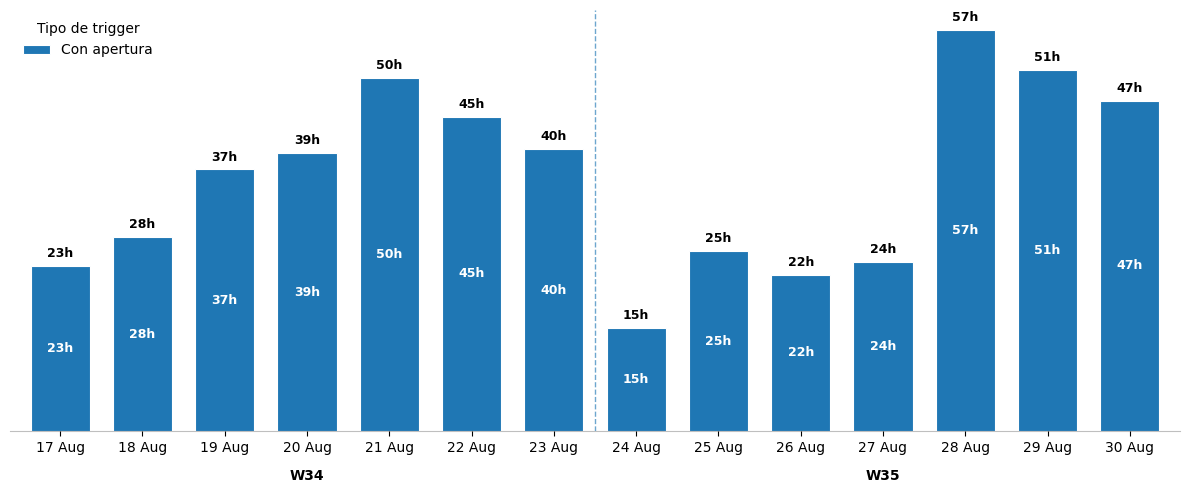

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

active_hours = (
    df_volume[df_volume["date"] > "2026-06-07"]
    .groupby(["date", "trigger_type"])["duration_minutes"]
    .sum()
    .div(60)
    .unstack(fill_value=0)
    .sort_index()
)

dates = pd.to_datetime(active_hours.index)
active_hours.index = dates.strftime("%d %b")

ax = active_hours.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    width=0.72,
    edgecolor="white",
    linewidth=0.8
)

# Guardar handles de barras ANTES de agregar axvline
handles, _ = ax.get_legend_handles_labels()

# Valores dentro de cada segmento
for container, col in zip(ax.containers, active_hours.columns):
    labels = [
        f"{v:.0f}h" if v >= 10 else ""
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        fontweight="bold",
        color="white" if col == "v1" else "black"
    )

# Total sobre cada barra
totals = active_hours.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + totals.max() * 0.015,
        f"{total:.0f}h",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Separación entre semanas
for i in range(1, len(dates)):
    if dates[i].isocalendar().week != dates[i - 1].isocalendar().week:
        ax.axvline(
            i - 0.5,
            linestyle="--",
            linewidth=1,
            alpha=0.65,
            label="_nolegend_"
        )

# Etiquetas de semana centradas bajo el eje X
week_numbers = dates.isocalendar().week.to_numpy()

week_groups = pd.DataFrame({
    "position": range(len(dates)),
    "week": week_numbers
})

for week, group in week_groups.groupby("week", sort=False):
    center = group["position"].mean()

    ax.text(
        center,
        -0.09,
        f"W{week}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        clip_on=False
    )

# ax.set_title(
#     "Horas activas por día y tipo de trigger",
#     loc="left",
#     fontsize=15,
#     fontweight="bold",
#     pad=18
# )

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_alpha(0.25)

ax.legend(
    handles=handles,
    labels=["Con apertura", "Sin apertura"],
    title="Tipo de trigger",
    frameon=False,
    ncol=1,
    # loc="upper left"
)

plt.xticks(rotation=0)
plt.margins(x=0.02)
plt.tight_layout()
plt.show()

## New Tables

### agupado por date

pasamos de granularidad trigger a granularidad diaria para comparar orders realizadas ese dia y lo que bloqueó cada trigger pero agrupado por dia también

In [11]:
# df_volume_vendor_date
print(f"Filas a nivel trigger: {len(df_volume):,}")
print(f"Rango de fechas: {df_volume['date'].min()} a {df_volume['date'].max()}")
print(f"Filas sin grade: {int(df_volume['grade'].isna().sum())}")
print("Filas por trigger_type:")
print(df_volume["trigger_type"].value_counts(dropna=False).to_string())

actual_order_columns = ["orders_vendor_date", "orders_vendor_date_seamless"]
vendor_date_variation = (
    df_volume
    .groupby(["date", "partner_id", "grade"], dropna=False)[actual_order_columns]
    .nunique(dropna=False)
)
inconsistent_vendor_dates = vendor_date_variation.gt(1).any(axis=1)
print(
    "Vendor-date con más de un valor de orders reales: "
    f"{int(inconsistent_vendor_dates.sum())}"
)
if inconsistent_vendor_dates.any():
    display(vendor_date_variation.loc[inconsistent_vendor_dates].head(20))

df_volume["estimated_orders_v1"] = df_volume["avg_orders_last_4_weeks_free_periods"].where(
    df_volume["trigger_type"] == "v1", 0
)

df_volume["estimated_orders_v2"] = df_volume["avg_orders_last_4_weeks_free_periods"].where(
    df_volume["trigger_type"] == "v2", 0
)

df_volume["estimated_orders_seamless_v1"] = df_volume["estimated_orders_seamless"].where(
    df_volume["trigger_type"] == "v1", 0
)

df_volume["estimated_orders_seamless_v2"] = df_volume["estimated_orders_seamless"].where(
    df_volume["trigger_type"] == "v2", 0
)

df_volume_vendor_date = (
    # df_volume[df_volume['date']>="2026-06-18"]
    df_volume
    .groupby(["date", "partner_id", "grade"], as_index=False)
    .agg(
        orders_vendor_date=("orders_vendor_date", "max"),
        orders_vendor_date_seamless=("orders_vendor_date_seamless", "max"),
        estimated_orders_v1=("estimated_orders_v1", "sum"),
        estimated_orders_v2=("estimated_orders_v2", "sum"),
        estimated_orders_seamless_v1=("estimated_orders_seamless_v1", "sum"),
        estimated_orders_seamless_v2=("estimated_orders_seamless_v2", "sum")
    )
)

print(f"Filas después de agrupar a vendor-date: {len(df_volume_vendor_date):,}")
print("Dtypes del resultado vendor-date:")
print(df_volume_vendor_date.dtypes.to_string())

df_volume_vendor_date.head(3)

Filas a nivel trigger: 2,770
Rango de fechas: 2026-08-17 a 2026-08-30
Filas sin grade: 0
Filas por trigger_type:
trigger_type
v1    2770
Vendor-date con más de un valor de orders reales: 0
Filas después de agrupar a vendor-date: 1,735
Dtypes del resultado vendor-date:
date                             object
partner_id                       object
grade                            object
orders_vendor_date              Float64
orders_vendor_date_seamless     Float64
estimated_orders_v1             Float64
estimated_orders_v2             Float64
estimated_orders_seamless_v1    Float64
estimated_orders_seamless_v2    Float64


,date,partner_id,grade,orders_vendor_date,orders_vendor_date_seamless,estimated_orders_v1,estimated_orders_v2,estimated_orders_seamless_v1,estimated_orders_seamless_v2
0,2026-08-17,103919,A,62.0,49.0,1.0,0.0,0.48,0.0
1,2026-08-17,109414,A,57.0,35.0,0.25,0.0,0.12,0.0
2,2026-08-17,111060,B,16.0,12.0,0.5,0.0,0.255,0.0


In [12]:
# dejamos las fechas del 18 en adelante, que es de donde cuando empieza el trigger v2
# df_volume_vendor_date = df_volume_vendor_date[df_volume_vendor_date['date']>="2026-06-18"]

### agrupado por grade

como ahora las estimaciones son diarias al igual que la metrica de orders de ese dia ese vendor, podemos ver cómo le fue a cada grade.

In [13]:
# agrupamos por grade
df_volume_grade = (
    df_volume_vendor_date
    # df_volume_vendor_date[(df_volume_vendor_date['date']>="2026-06-18")& (df_volume_vendor_date['date']<="2026-06-23")]
    .groupby("grade", as_index=False)
    .agg(
        orders_vendor_date=("orders_vendor_date", "sum"),
        orders_vendor_date_seamless=("orders_vendor_date_seamless", "sum"),
        estimated_orders_v1=("estimated_orders_v1", "sum"),
        estimated_orders_v2=("estimated_orders_v2", "sum"),
        estimated_orders_seamless_v1=("estimated_orders_seamless_v1", "sum"),
        estimated_orders_seamless_v2=("estimated_orders_seamless_v2", "sum")
    )
)

df_volume_grade

,grade,orders_vendor_date,orders_vendor_date_seamless,estimated_orders_v1,estimated_orders_v2,estimated_orders_seamless_v1,estimated_orders_seamless_v2
0,,15.0,7.0,3.17,0.0,0.0,0.0
1,A,20906.0,17264.0,927.62,0.0,445.2576,0.0
2,AA,3925.0,3159.0,134.57,0.0,57.8651,0.0
3,AAA,2579.0,1801.0,202.49,0.0,70.8715,0.0
4,B,10340.0,8620.0,419.91,0.0,214.1541,0.0
5,C,4574.0,3557.0,151.0,0.0,66.44,0.0
6,D,638.0,427.0,16.24,0.0,10.7184,0.0
7,NA,8.0,3.0,0.0,0.0,0.0,0.0


In [14]:
# estimamos de cuánto fue el saved seamless de cada grade

df_volume_grade["seamless_real"] = (
    df_volume_grade["orders_vendor_date_seamless"]
    / df_volume_grade["orders_vendor_date"]
)

df_volume_grade["seamless_v1"] = (
    df_volume_grade["orders_vendor_date_seamless"]
    + df_volume_grade["estimated_orders_seamless_v1"]
) / (
    df_volume_grade["orders_vendor_date"]
    + df_volume_grade["estimated_orders_v1"]
)

df_volume_grade["seamless_v1v2"] = (
    df_volume_grade["orders_vendor_date_seamless"]
    + df_volume_grade["estimated_orders_seamless_v1"]
    + df_volume_grade["estimated_orders_seamless_v2"]
) / (
    df_volume_grade["orders_vendor_date"]
    + df_volume_grade["estimated_orders_v1"]
    + df_volume_grade["estimated_orders_v2"]
)

# df_volume_grade[["seamless_real", "seamless_v1", "seamless_v1v2"]] *= 100
df_volume_grade
df_volume_grade[["grade","seamless_real", "seamless_v1", "seamless_v1v2"]]

,grade,seamless_real,seamless_v1,seamless_v1v2
0,,0.466667,0.38525,0.38525
1,A,0.825792,0.8111,0.8111
2,AA,0.804841,0.792415,0.792415
3,AAA,0.698333,0.672974,0.672974
4,B,0.833656,0.821025,0.821025
5,C,0.777656,0.766866,0.766866
6,D,0.669279,0.669049,0.669049
7,NA,0.375,0.375,0.375


### saved seamless general

In [15]:
# estimamos de cuánto fue el saved seamless general

df_volume_total = pd.DataFrame({
    "orders_vendor_date": [df_volume_grade["orders_vendor_date"].sum()],
    "orders_vendor_date_seamless": [df_volume_grade["orders_vendor_date_seamless"].sum()],
    "estimated_orders_v1": [df_volume_grade["estimated_orders_v1"].sum()],
    "estimated_orders_v2": [df_volume_grade["estimated_orders_v2"].sum()],
    "estimated_orders_seamless_v1": [df_volume_grade["estimated_orders_seamless_v1"].sum()],
    "estimated_orders_seamless_v2": [df_volume_grade["estimated_orders_seamless_v2"].sum()]
})

df_volume_total["seamless_real"] = (
    df_volume_total["orders_vendor_date_seamless"]
    / df_volume_total["orders_vendor_date"]
)

df_volume_total["seamless_v1"] = (
    df_volume_total["orders_vendor_date_seamless"]
    + df_volume_total["estimated_orders_seamless_v1"]
) / (
    df_volume_total["orders_vendor_date"]
    + df_volume_total["estimated_orders_v1"]
)

df_volume_total["seamless_v1v2"] = (
    df_volume_total["orders_vendor_date_seamless"]
    + df_volume_total["estimated_orders_seamless_v1"]
    + df_volume_total["estimated_orders_seamless_v2"]
) / (
    df_volume_total["orders_vendor_date"]
    + df_volume_total["estimated_orders_v1"]
    + df_volume_total["estimated_orders_v2"]
)

df_volume_total[["seamless_real", "seamless_v1", "seamless_v1v2"]]

,seamless_real,seamless_v1,seamless_v1v2
0,0.810469,0.796238,0.796238


### orders real/bloqueadas seamless/NS

In [16]:
df_summary = pd.DataFrame(
    {
        "orders": [
            df_volume_total["orders_vendor_date"].iloc[0],
            df_volume_total["estimated_orders_v1"].iloc[0]
            + df_volume_total["estimated_orders_v2"].iloc[0]
        ],
        "orders_seamless": [
            df_volume_total["orders_vendor_date_seamless"].iloc[0],
            df_volume_total["estimated_orders_seamless_v1"].iloc[0]
            + df_volume_total["estimated_orders_seamless_v2"].iloc[0]
        ]
    },
    index=["real", "bloqueadas"]
)

df_summary.round()

,orders,orders_seamless
real,42985.0,34838.0
bloqueadas,1855.0,865.0


In [17]:
df_summary = pd.DataFrame(
    {
        "orders": [
            df_volume_total["orders_vendor_date"].iloc[0],
            (
                df_volume_total["estimated_orders_v1"].iloc[0]
                + df_volume_total["estimated_orders_v2"].iloc[0]
            )
        ],
        "orders_seamless": [
            df_volume_total["orders_vendor_date_seamless"].iloc[0],
            (
                df_volume_total["estimated_orders_seamless_v1"].iloc[0]
                + df_volume_total["estimated_orders_seamless_v2"].iloc[0]
            )
        ]
    },
    index=["real", "bloqueadas"]
)

# Agregar fila total
df_summary.loc["total"] = df_summary.sum()

# Calcular seamless para cada fila
df_summary["seamless"] = (
    df_summary["orders_seamless"]
    / df_summary["orders"]
)

df_summary["seamless"] = (
    df_summary["orders_seamless"]
    / df_summary["orders"]
    * 100
)

df_summary.round(
    {
        "orders": 0,
        "orders_seamless": 0,
        "seamless": 3
    }
)

,orders,orders_seamless,seamless
real,42985.0,34838.0,81.047
bloqueadas,1855.0,865.0,46.647
total,44840.0,35703.0,79.624


In [18]:
saved_seamless = df_summary.loc["real", "seamless"] - df_summary.loc["total", "seamless"]
print(saved_seamless.round(3))

1.423


### orders bloqueadas por grade y trigger

In [19]:
df_volume_grade_trigger = (
    df_volume
    # df_volume[df_volume['date']>="2026-06-18"]
    .groupby(["grade", "trigger_type"], as_index=False) # porque las orders las tenemos por vendor date
    .agg(
        estimated_orders=("avg_orders_last_4_weeks_free_periods", "sum"),
        # estimated_orders_seamless=("estimated_orders_seamless", "sum")
    )
)

df_volume_grade_trigger.round(0)

df_volume_grade_trigger_pivot = df_volume_grade_trigger.pivot_table(
    # index="trigger_type",
    index="grade",
    # columns="grade",
    columns="trigger_type",
    values="estimated_orders",
    aggfunc="sum",
    fill_value=0
)

df_volume_grade_trigger_pivot.round()

trigger_type,v1
grade,
,3.0
A,928.0
AA,135.0
AAA,202.0
B,420.0
C,151.0
D,16.0
NA,0.0
